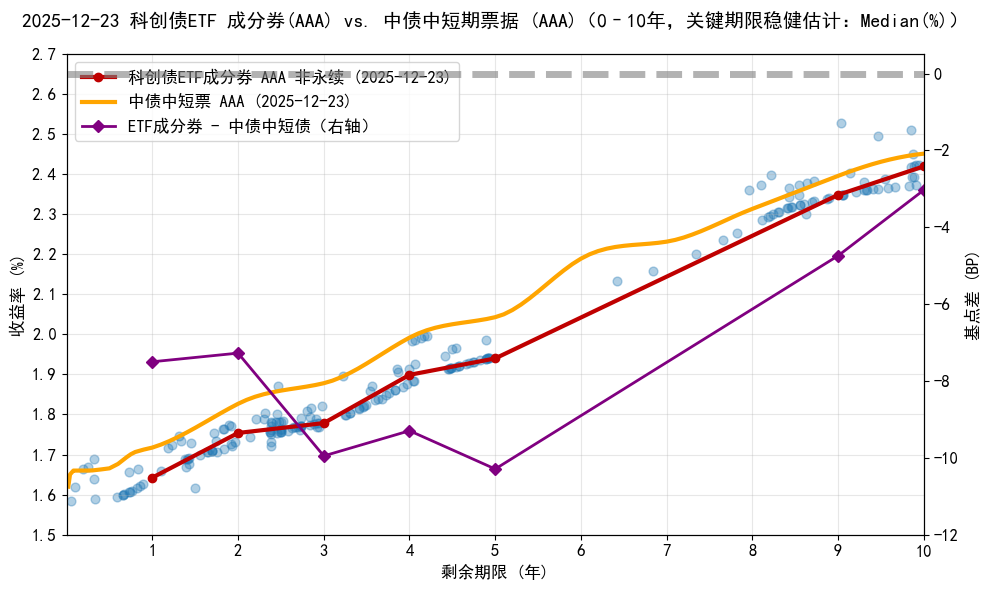

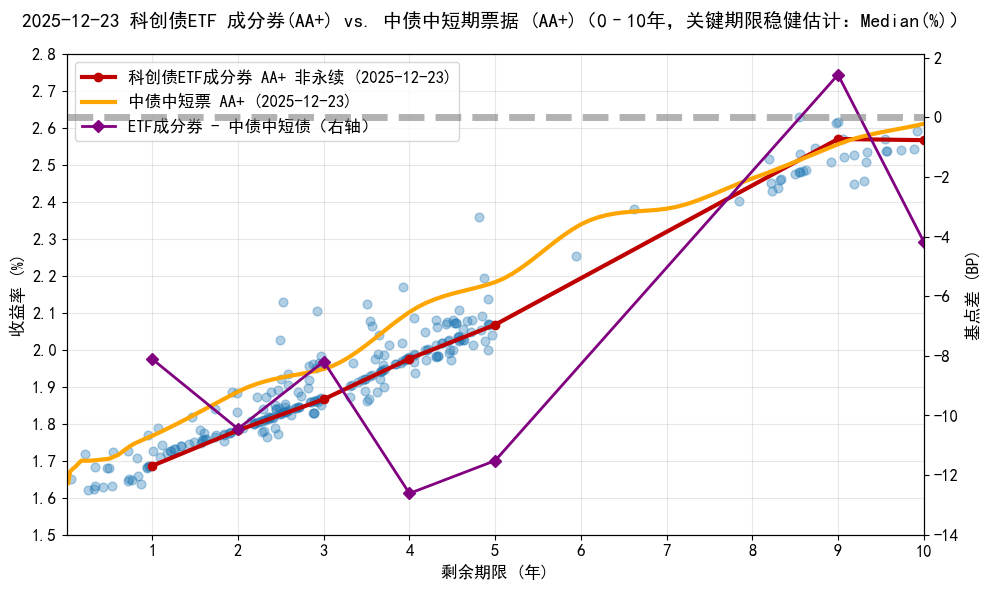

100%|██████████| 14/14 [00:56<00:00,  4.03s/it]


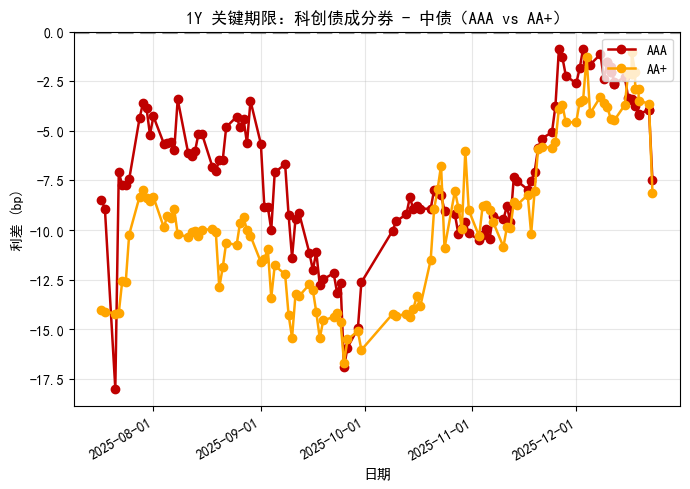

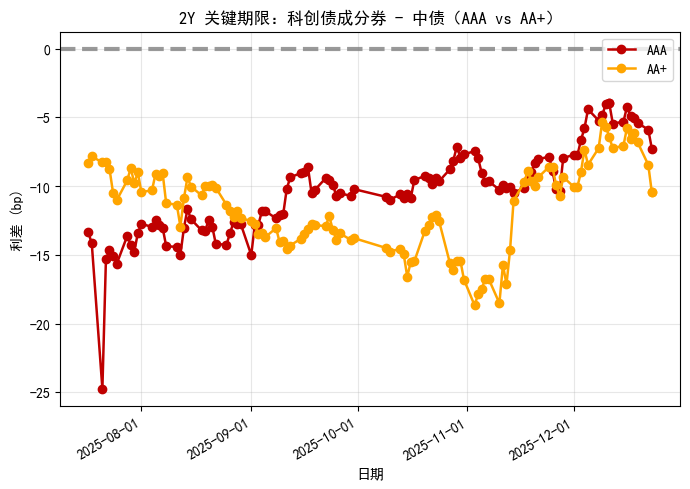

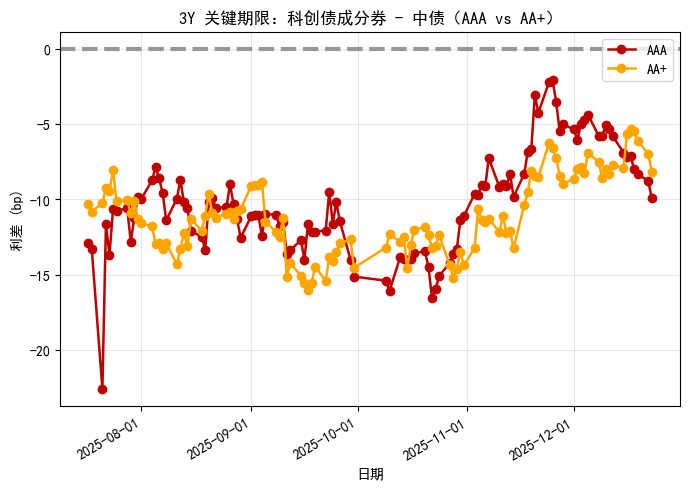

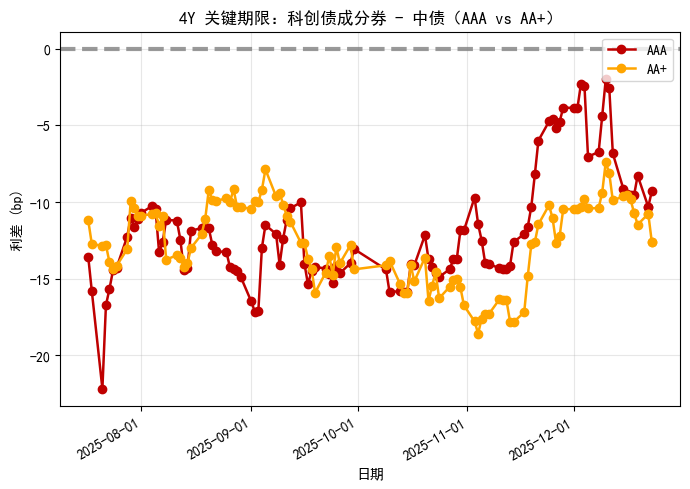

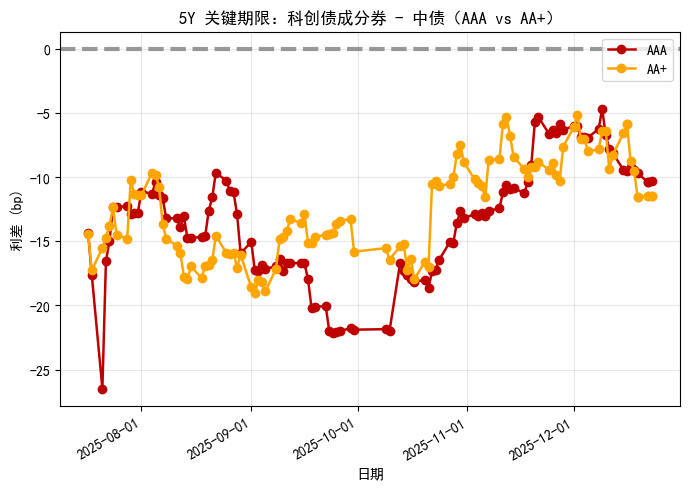

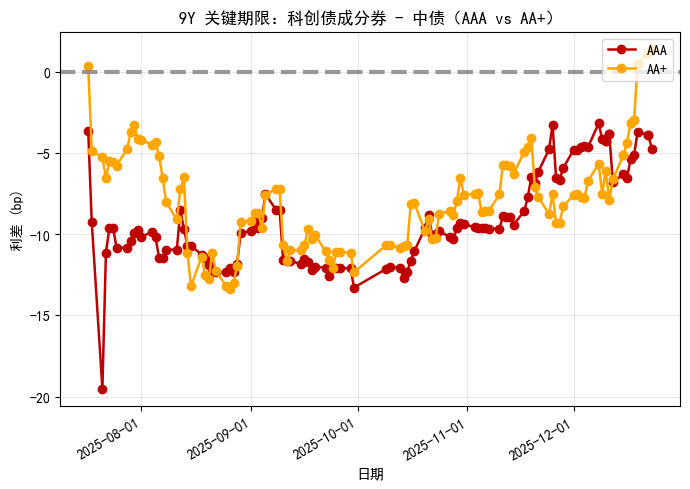

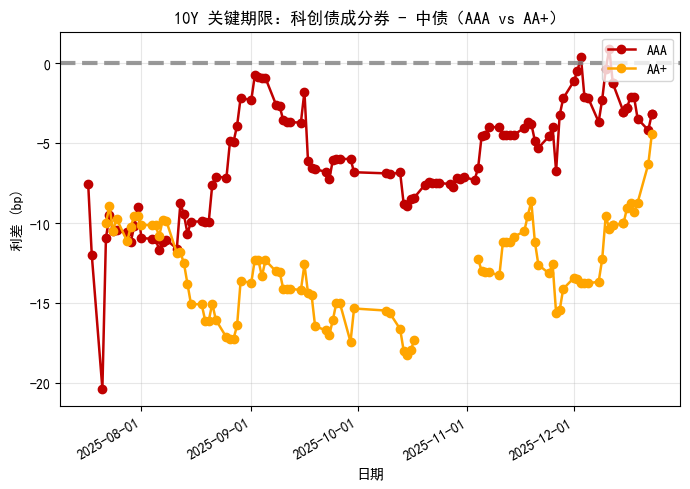

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import minimize
import datetime as dt
from WindPy import w
w.start()
plt.rcParams['font.sans-serif'] = ['SimHei'] # 设置字体为黑体
plt.rcParams['axes.unicode_minus'] = False # 解决坐标轴负号显示问题
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm


###########******************** 获取科创债成分券信息 ******************###########
###########***************************************************###########
###########***************************************************###########
# 读取交易日历，获取最新交易日作为数据截止日期
data_日期 =pd.read_excel('交易日历_更新.xlsx')
date=data_日期['上一个交易日'][0].strftime('%Y-%m-%d')  # 结束日期
date_today= data_日期['今天'][0]  # 今日 / 最后日期
rating='AA+'
rating_list=['AAA','AA+']  # 评级列表

## 科创债ETF名称及代码
dict_etf = {
    '159200.SZ': '科创债ETF富国',
    '159400.SZ': '科创债ETF景顺',
    '159600.SZ': '科创债ETF嘉实',
    '159700.SZ': '科创债ETF南方',
    '511120.SH': '科创债ETF广发',
    '551030.SH': '科创债ETF鹏华',
    '551500.SH': '科创债ETF易方达',
    '551550.SH': '科创债ETF华夏',
    '551900.SH': '科创债ETF招商',
}


data_pcf=pd.DataFrame()
for code, name in dict_etf.items():
    df_temp = w.wset("etfconstituent","date="+date+";windcode="+code,usedf=True)[1]
    data_pcf=pd.concat([data_pcf,df_temp])


bond_codes=data_pcf['wind_code']
bond_codes= bond_codes.drop_duplicates().to_list()  # 去重


# 通过 WindPy 批量获取每只债券的剩余期限、隐含评级、成交收益率和估值收益率
# 注意：若无成交收益率则以估值收益率代替
# 尝试获取“剩余期限(年)”字段；对于永续债，将考虑其首个行权日期作为剩余期限
fields = ["remaining_maturity", "implied_rating", "yield_latest", "yield_valuation"]
# 上述字段名称需替换为 Wind 实际字段:
# 假设 remaining_maturity 自动考虑行权，如未考虑则需自行计算永续债首个行权期限
data1 = w.wss(bond_codes,"ptmyear,rate_latestMIR_cnbd,ytm_b,yield_cnbd","tradeDate="+date+";returnType=1;credibility=1;date="+date)
data = w.wss(bond_codes,"termifexercise,rate_latestMIR_cnbd,ytm_b,yield_cnbd","tradeDate="+date+";returnType=1;credibility=1;date="+date)

# 检查 Wind API 返回数据是否正常
if data.ErrorCode != 0:
    raise Exception(f"Wind数据获取失败，错误码: {data.ErrorCode}")

# 提取返回的数据列并转为 DataFrame 方便处理
rem_years = data.Data[0]   # 剩余期限(年)
ratings = data.Data[1]     # 隐含评级
yld_valuation = data.Data[3]  # 中债估值收益率(估值收益率)
yld_trade = data.Data[2]      # 最近成交收益率

data_temp = pd.DataFrame([rem_years,data1.Data[0]]).T
# 将第0列里的 NaN 用第1列对应位置的值填上
data_temp[0] = data_temp[0].fillna(data_temp[1])
rem_years = list(data_temp[0])

bond_df = pd.DataFrame({
    'Code': data.Codes,
    'RemainingYears': rem_years,
    'ImpliedRating': ratings,
    'TradeYield': yld_trade,
    'ValuationYield': yld_valuation
})

# 将“是否永续债”信息合并到数据表
bond_df['IsPerpetual'] =w.wsd(bond_df['Code'].to_list(), "perpetualornot",date, date, "",usedf=True)[1]['PERPETUALORNOT'].to_list()

from scipy.interpolate import PchipInterpolator 
# 数据筛选：仅保留隐含评级为 AAA 或 AA+ 的债券
bond_df = bond_df[bond_df['ImpliedRating'].isin(['AAA', 'AA+'])]
bond_df.reset_index(drop=True, inplace=True)

# 计算每支债券最终用于分析的收益率：有成交收益率用成交收益率，否则用估值收益率
bond_df['YieldUsed'] = bond_df.apply(
    lambda row: row['ValuationYield'] if not pd.isna( row['ValuationYield']) else row['ValuationYield'],
    axis=1
)

bond_df_output=bond_df.drop(columns=['TradeYield','YieldUsed'])
#.to_excel(date+'科创债ETF成分券估值相关信息.xlsx')

bond_df_output.columns=['代码','剩余期限','隐含评级','中债估值','是否永续']
bond_df_output = bond_df_output[bond_df_output['是否永续']=='否']

### 创建文件夹'D:/工作相关_杂杂杂/科创债ETF曲线构建/邮件图片文件夹/{date}'
import os
output_dir = f'./邮件图片文件夹/{date}'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

bond_df_output.to_excel(f'./邮件图片文件夹/{date}/{date}科创债ETF成分券估值相关信息.xlsx',index=False)



# ================= 参数（可按需调整） =================
#KEY_TENORS = # 0.2 年步长，覆盖 0.2–10.0 年（不含 0）
#KEY_TENORS = np.round(np.array([0.5]).append(np.arange(1, 10.0 + 1e-9, 1)), 1).astype(float)
KEY_TENORS = [1,2,3,4,5,9,10]#np.round(np.arange(1, 11),1).astype(float)
#KEY_TENORS = np.concatenate(([0.1], KEY_TENORS))

    #np.concatenate(([0.5], np.arange(1, 11))), 1   # 拼接后保留 1 位小数


#np.array([1, 2, 3, 4, 5, 7, 10], dtype=float)
HALF_WINDOW = 0.1        # 关键期限的半窗宽（年）
MAX_HALF_WINDOW = 0.25#0.75    # 最大可扩到的半窗宽
STEP = 0.125              # 扩窗步长
MAD_K =3.5               # MAD 离群阈值（3.0~3.5 常用）
TRIM_ALPHA = 0.10         # 截尾均值两端各截去比例
MIN_POINTS = 5          # 去噪后最少样本数
ESTIMATOR = "Median(%)"   # 可选: "Median(%)" / "Mean(%)" / "TrimmedMean(%)"

# ================= 稳健窗口估计工具 =================
def _mad_mask(y, k=MAD_K):
    if len(y) == 0:
        return np.zeros(0, dtype=bool)
    m = np.median(y)
    mad = np.median(np.abs(y - m)) + 1e-12
    z = np.abs(y - m) / (1.4826 * mad)
    return z <= k

def _trimmed_mean(y, alpha=TRIM_ALPHA):
    if len(y) == 0:
        return np.nan
    y_sorted = np.sort(np.asarray(y))
    n = len(y_sorted)
    k = int(np.floor(alpha * n))
    if n - 2*k <= 0:
        return np.nan
    return y_sorted[k:n-k].mean()

def robust_tenor_stats(x, y, tenors=KEY_TENORS,
                    half_window=HALF_WINDOW, max_half_window=MAX_HALF_WINDOW, step=STEP,
                    mad_k=MAD_K, min_points=MIN_POINTS, trim_alpha=TRIM_ALPHA):
    """对每个关键期限 T，在 [T±half_window] 内取样；不够就扩窗；MAD 去噪后给中位/均值/截尾均值等"""
    x = np.asarray(x, float); y = np.asarray(y, float)
    out = []
    for T in tenors:
        if not (0 < T <= 10):
            continue
        hw = half_window
        chosen_vals = None
        n_raw = 0
        while hw <= max_half_window:
            m = (x >= T - hw) & (x <= T + hw)
            y_win = y[m]
            n_raw = int(m.sum())
            keep = _mad_mask(y_win, k=mad_k)
            y_used = y_win[keep]
            if len(y_used) >= min_points:
                chosen_vals = y_used
                break
            hw += step
        if chosen_vals is None:
            # 尝试用最大窗宽、不过滤，作为兜底估计
            m = (x >= T - min(hw, max_half_window)) & (x <= T + min(hw, max_half_window))
            y_win = y[m]
            n_raw = int(m.sum())
            if n_raw == 0:
                out.append({"Term(years)": T, "Window(±yrs)": np.nan, "N_raw": 0, "N_used": 0,
                            "Median(%)": np.nan, "Mean(%)": np.nan, "TrimmedMean(%)": np.nan, "StdUsed": np.nan})
                continue
            chosen_vals = y_win
            hw = min(hw, max_half_window)
        n_used = len(chosen_vals)
        out.append({
            "Term(years)": float(T),
            "Window(±yrs)": round(min(hw, max_half_window), 3),
            "N_raw": int(n_raw),
            "N_used": int(n_used),
            "Median(%)": float(np.median(chosen_vals)),
            "Mean(%)": float(np.mean(chosen_vals)),
            "TrimmedMean(%)": float(_trimmed_mean(chosen_vals, alpha=trim_alpha)),
            "StdUsed": float(np.std(chosen_vals, ddof=1)) if n_used >= 2 else np.nan,
        })
    return pd.DataFrame(out)



for rating in rating_list:

    bond_df=bond_df[bond_df['IsPerpetual'] == '否']  # 仅保留非永续债
    bond_df_rating = bond_df[bond_df['ImpliedRating']==rating] # 仅保留 AAA 评级债券


    # ------------------------------------------------------------------
    # 2. 读入中债曲线 Excel
    # ------------------------------------------------------------------
    if rating == 'AAA':
        curve_df = pd.read_excel('期限结构_中债AAA_历史.xlsx')#)#
        
    elif rating == 'AA+':
        curve_df = pd.read_excel("期限结构_中债AA+_历史.xlsx")
    else:
        raise ValueError("不支持的评级类型，请选择 'AAA' 或 'AA+'")

    # ------ !! 根据实际列名做映射 -----------------
    #col_curve  = '曲线名称'     # 曲线名称列
    col_term   = '期限(年)'     # 剩余期限列
    col_yield  = pd.to_datetime(date)   # 收益率列
    # curve_df = curve_df[curve_df[col_curve] \
    #            == '中债中短期票据收益率曲线(AAA)(到期)[2025-07-30]'].copy()

    curve_df[col_term] = curve_df[col_term].astype(float)
    curve_df[col_yield]= curve_df[col_yield].astype(float)
    curve_df = curve_df.dropna(subset=[col_term,col_yield])

    x_off  = curve_df[col_term].values
    y_off  = curve_df[col_yield].values

    # ================= 1) 计算 ETF 与官方在关键期限的稳健点 =================
    # ETF 数据
    df_etf = (bond_df_rating.loc[:, ["RemainingYears", "YieldUsed"]]
                    .rename(columns={"RemainingYears": "T", "YieldUsed": "Y"})
                    .dropna())
    df_etf = df_etf[(df_etf["T"] > 0) & (df_etf["T"] <= 10)].copy()


    

    etf_table = robust_tenor_stats(df_etf["T"].to_numpy(), df_etf["Y"].to_numpy(),
                                tenors=KEY_TENORS, half_window=HALF_WINDOW,
                                max_half_window=MAX_HALF_WINDOW, step=STEP,
                                mad_k=MAD_K, min_points=MIN_POINTS, trim_alpha=TRIM_ALPHA)




    # 官方数据（x_off / y_off 来自你读入的中债表）
    off_mask = (x_off > 0) & (x_off <= 10) & np.isfinite(y_off)
    off_table = robust_tenor_stats(x_off[off_mask], y_off[off_mask],
                                tenors=KEY_TENORS, half_window=HALF_WINDOW,
                                max_half_window=MAX_HALF_WINDOW, step=STEP,
                                mad_k=MAD_K, min_points=1, trim_alpha=TRIM_ALPHA)

    # 对齐关键期限，拿同一估计口径（ESTIMATOR）计算 bp
    df_merged = (etf_table.merge(off_table[["Term(years)", ESTIMATOR]].rename(columns={ESTIMATOR:"Off(%)"}),
                                on="Term(years)", how="inner"))
    df_merged["ETF(%)"] = df_merged[ESTIMATOR]
    df_merged["Spread(bp)"] = (df_merged["ETF(%)"] - df_merged["Off(%)"]) * 100.0

    # 去掉NaN
    df_plot = df_merged.dropna(subset=["ETF(%)", "Off(%)"]).sort_values("Term(years)")

    # ================= 2) 画图：左轴=收益率（散点+关键期限折线），右轴=bp =================
    plt.figure(figsize=(10, 6))
    ax1 = plt.gca()

    # 原始散点（0–10年）
    ax1.scatter(df_etf["T"], df_etf["Y"], alpha=0.35, s=40, label="原始散点 (0–10年)")

    # ETF 关键期限点（稳健估计）—— 折线+圆点
    ln1, = ax1.plot(df_plot["Term(years)"], df_plot["ETF(%)"],
                    lw=3, marker="o", label="科创债ETF成分券 "+rating+f" 非永续 ({date})",color='#bf0000')

    # 官方曲线（0–10 年原样连线，或用关键期限点）
    m_off = (x_off > 0) & (x_off <= 10)
    ln2, = ax1.plot(x_off[m_off], y_off[m_off], '-', color='orange', lw=3,
                    label='中债中短票 '+rating+' ('+date+')')

    # 左轴：收益率
    ax1.set_xlabel('剩余期限 (年)',fontsize=12)
    ax1.set_ylabel('收益率 (%)',fontsize=12)
    ax1.set_xlim(0, 10)
    ax1.set_ylim(bottom=1.5)
    ax1.set_xticks([1,2,3,4,5,6,7,8,9,10])
    ax1.tick_params(axis='x', labelsize=12)
    ax1.tick_params(axis='y', labelsize=12)
    ax1.grid(alpha=.3)

    # 左轴步长 0.1
    ymin, ymax = ax1.get_ylim()
    ax1.set_yticks(np.arange(round(ymin,1), round(ymax+0.2,1), 0.1))

    

    # 右轴：关键期限基点差（ETF - 官方）
    ax2 = ax1.twinx()
    ln3, = ax2.plot(df_plot["Term(years)"], df_plot["Spread(bp)"],
                    '-', color='purple', lw=2, marker="D", label='ETF成分券 - 中债中短债（右轴）')
    ax2.set_ylabel('基点差 (BP)',fontsize=12)
    ax2.tick_params(axis='y', labelsize=12)
    ax2.axhline(0, color='grey', lw=5, ls='--', alpha=.6)

    # 右轴步长 2
    ymin2, ymax2 = ax2.get_ylim()
    ax2.set_yticks(np.arange(int(ymin2//2*2), int(ymax2+2), 2))

    # 图例合并
    lns = [ln1, ln2, ln3]
    labels = [l.get_label() for l in lns]
    ax1.legend(lns, labels, loc='upper left', fontsize=12)

    plt.xticks(fontsize=12)
    plt.title(date+ f' 科创债ETF 成分券({rating}) vs. 中债中短期票据 ({rating})（0–10年，关键期限稳健估计：{ESTIMATOR}）', fontsize=14,pad=20)
    plt.tight_layout()
    ###导出图片到 D:\工作相关_杂杂杂\科创债ETF曲线构建\邮件图片文件夹
    plt.savefig(f'./邮件图片文件夹/{date}/{date}科创债ETF成分券vs中债中短票据_{rating}.png', dpi=300) 
    plt.show()

    df_all_data=pd.read_excel(f'./科创债ETF成分券vs中债中短票据_利差时间序列.xlsx')


# -------------- 自定义参数 -----------------------------
END_DATE   = date_today #dt.date(2025, 8, 20)   # 今日 / 最后日期

KEY_TENORS = np.array([1,2,3,4,5,9,10]).astype(float)   # 关键期限
ESTIMATOR  = "Median(%)"            # or "TrimmedMean(%)"
ETF_DICT = {
    '159200.SZ':'科创债ETF富国', '159400.SZ':'科创债ETF景顺',
    '159600.SZ':'科创债ETF嘉实', '159700.SZ':'科创债ETF南方',
    '511120.SH':'科创债ETF广发', '551030.SH':'科创债ETF鹏华',
    '551500.SH':'科创债ETF易方达', '551550.SH':'科创债ETF华夏',
    '551900.SH':'科创债ETF招商',
}

# -------------- 时间序列 -------------------------------


date_list = [
    (END_DATE - dt.timedelta(days=i))
    for i in range(1, 15)            # 1 到 15 天前
]


# ---------------- 读入中债曲线（分别为 AAA / AA+） ----------------
curve_map = {}
for rtg, fn in [('AAA', '期限结构_中债AAA_历史.xlsx'),
                ('AA+', '期限结构_中债AA+_历史.xlsx')]:
    dfc = pd.read_excel(fn).replace(0, np.nan).dropna(axis=1, how='all')
    # 识别日期列
    date_cols = []
    for c in dfc.columns:
        if c == '期限(年)': 
            continue
        try:
            # 能被解析为日期的列才保留
            _ = pd.to_datetime(c)
            date_cols.append(c)
        except Exception:
            pass
    dfc = dfc[['期限(年)'] + date_cols]
    curve_map[rtg] = dfc

# ---------------- 主循环：逐日、逐评级计算 ----------------
w.start()
rows = []   # {Date, Tenor, Rating, Spread}

for d in tqdm(sorted(date_list)):
    ds = d.strftime('%Y-%m-%d')
    d8 = d.strftime('%Y%m%d')

    # 1) 取当天所有科创债ETF的成分券（一次获取，供两个评级复用）
    df_pcf = pd.concat([
        w.wset("etfconstituent", f"date={ds};windcode={code}", usedf=True)[1]
        for code in ETF_DICT
    ], ignore_index=True)

    if df_pcf.empty:
        continue

    bond_codes = df_pcf['wind_code'].drop_duplicates().tolist()
    info = w.wss(
        bond_codes,
        "ptmyear,rate_latestMIR_cnbd,yield_cnbd",
        f"tradeDate={d8};returnType=1;credibility=1;date={d8}"
    )
    if info.ErrorCode != 0:
        continue

    info1 = w.wss(
        bond_codes,
        "termifexercise,rate_latestMIR_cnbd,yield_cnbd",
        f"tradeDate={d8};returnType=1;credibility=1;date={d8}"
    )
    if info.ErrorCode != 0:
        continue

    data_temp = pd.DataFrame([info1.Data[0],info.Data[0]]).T
    # 将第0列里的 NaN 用第1列对应位置的值填上
    data_temp[0] = data_temp[0].fillna(data_temp[1])
    rem_years = list(data_temp[0])


    df_b = pd.DataFrame({
        "code": info.Codes,
        "T"   : rem_years,#info.Data[0],   # 剩余期限(年)
        "rat" : info.Data[1],   # 中债隐含评级
        "Y"   : info.Data[2],   # 中债估值收益率
    })

    # 非永续标识
    perp = w.wsd(df_b['code'].tolist(), "perpetualornot", ds, ds, "", usedf=True)[1]['PERPETUALORNOT'].to_numpy()
    df_b['perp'] = perp

    # 仅 0<T<=10 且收益率>0
    df_b = df_b[(df_b['T'] > 0) & (df_b['T'] <= 10) & (df_b['Y'] > 0)].copy()
    if df_b.empty:
        continue

    # 2) 分评级处理（AAA、AA+）
    for rating in ['AAA', 'AA+']:
        # 官方曲线是否有该日
        cdf = curve_map[rating]
        if pd.to_datetime(ds) not in cdf.columns:
            # 如果列名是字符串日期，尝试匹配
            cols = [c for c in cdf.columns if c != '期限(年)' and str(pd.to_datetime(c).date()) == ds]
            if not cols:
                continue
            col_date = cols[0]
        else:
            col_date = pd.to_datetime(ds)

        # 2.1 ETF 侧：该评级、非永续
        df_b_r = df_b[(df_b['rat'] == rating) & (df_b['perp'] == '否')].copy()
        if df_b_r.empty:
            continue

        # 用 robust_tenor_stats 计算 ETF 在 KEY_TENORS 的稳健点
        etf_tab = robust_tenor_stats(
            df_b_r['T'].to_numpy(), df_b_r['Y'].to_numpy(),
            tenors=KEY_TENORS,
            half_window=HALF_WINDOW, max_half_window=MAX_HALF_WINDOW, step=STEP,
            mad_k=MAD_K, min_points=MIN_POINTS, trim_alpha=TRIM_ALPHA
        )[["Term(years)", ESTIMATOR]].rename(columns={ESTIMATOR: "ETF(%)"})

        # 2.2 官方侧：同样用 robust_tenor_stats（允许 min_points=1）
        x_off = cdf['期限(年)'].astype(float).to_numpy()
        y_off = cdf[col_date].astype(float).to_numpy()
        m = np.isfinite(x_off) & np.isfinite(y_off)
        x_off, y_off = x_off[m], y_off[m]
        if len(x_off) == 0:
            continue

        off_tab = robust_tenor_stats(
            x_off, y_off,
            tenors=KEY_TENORS,
            half_window=HALF_WINDOW, max_half_window=MAX_HALF_WINDOW, step=STEP,
            mad_k=MAD_K, min_points=1, trim_alpha=TRIM_ALPHA
        )[["Term(years)", ESTIMATOR]].rename(columns={ESTIMATOR: "Off(%)"})

        # 2.3 合并并计算利差(bp)
        merged = (etf_tab.merge(off_tab, on="Term(years)", how="inner")
                         .rename(columns={"Term(years)": "Tenor"}))
        if merged.empty:
            continue

        merged["Date"] = d
        merged["Rating"] = rating
        merged["Spread(bp)"] = (merged["ETF(%)"] - merged["Off(%)"]) * 100.0
        rows.append(merged[["Date", "Tenor", "Rating", "Spread(bp)"]])

# 汇总
df_all = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
df_all['Date']=pd.to_datetime(df_all['Date'])


if df_all.empty:
    raise RuntimeError("没有可用数据生成图表（请检查日期/官方曲线/ETF数据）。")

df_all = pd.concat([df_all,df_all_data]).drop_duplicates()
df_all.to_excel(f'./科创债ETF成分券vs中债中短票据_利差时间序列.xlsx',index=False)


# ---------------- 画 6 个独立图：每图=一个期限，AA+ & AAA 的利差（bp） ----------------
import matplotlib.dates as mdates

for T in KEY_TENORS:
    sub = df_all[df_all["Tenor"] == T].sort_values("Date")
    if sub.empty:
        continue

    fig, ax = plt.subplots(figsize=(7, 5))

    # 逐评级画线
    drew_any = False
    for rating, color in [('AAA', '#bf0000'), ('AA+', 'orange')]:
        s = sub[sub["Rating"] == rating]
        if s.empty:
            continue
        ax.plot(s["Date"], s["Spread(bp)"], marker='o', lw=1.8,
                color=color, label=rating)
        drew_any = True

    if not drew_any:
        plt.close(fig)
        continue

    # 零轴、坐标轴与样式
    ax.axhline(0, ls='--', lw=3, color='grey', alpha=.8)
    ax.set_ylabel('利差 (bp)')
    ax.set_xlabel('日期')
    ax.set_title(f'{T:g}Y 关键期限：科创债成分券 - 中债（AAA vs AA+）')

    ax.grid(alpha=.3)
    ax.legend(loc='upper right')

    # 日期美化
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate()

    plt.tight_layout()

    ### 保存图片到 \邮件图片文件夹
    plt.savefig(f'./邮件图片文件夹/{date}/{date}科创债ETF成分券vs中债_{int(T)}Y.png', dpi=300)
    #plt.show()
    # 如需保存成文件，取消下一行注释：
    # fig.savefig(f'spread_{int(T)}Y.png', dpi=150, bbox_inches='tight')

             